In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import os
import torch
from tqdm.auto import tqdm

from JacobianODE.jacobians import (
    load_config,
    initialize_config,
    seed_everything,
    make_trajectories,
    postprocess_data,
)
from JacobianODE.fnn import loss_amplification, loss_false
from JacobianODE.jacobians.data import embed_signal_torch

In [4]:
# ----------------------------------------------------------------
# Data source: "dysts" or "wmtask"
# ----------------------------------------------------------------
DATA_SOURCE = "dysts"   # <-- change to "wmtask" for WM task RNN data
# DATA_SOURCE = "wmtask"

# ----------------------------------------------------------------
# wmtask-specific hyperparameters (ignored when DATA_SOURCE="dysts")
# ----------------------------------------------------------------
WMTASK_PROJECT = "WMSelectionTask__cue_time_0.1__response_time_0.25__enforce_fixation_False"
WMTASK_NAME = "BiologicalRNN__cue_time_0.1__learning_rate_0.0005__max_epochs_42__N1_64__N2_64__tau_0.05__dt_0.02__eig_lower_bound_0.1__init_mode_random"
WMTASK_MODEL_TO_LOAD = "final"
WMTASK_DATALOADER = "all"
WMTASK_TRAJ_WINDOW = "delay2"
WMTASK_DIM = 128  # N1 + N2 = 64 + 64

# For wmtask: which dimensions to use for delay embedding.
# "all" = use full 128-dim hidden state; or a list of indices, e.g. [0], [0, 1, 2], or list(range(42))
# WMTASK_OBSERVED_INDICES = "all"
USE_PARTIAL_OBS = True
N_PARTIAL_OBS = 42
PARTIAL_OBS_SEED = 42
if USE_PARTIAL_OBS:
    np.random.seed(PARTIAL_OBS_SEED)
    WMTASK_OBSERVED_INDICES = sorted(np.random.choice(WMTASK_DIM, N_PARTIAL_OBS, replace=False).tolist())
else:
    WMTASK_OBSERVED_INDICES = "all"

In [5]:
# Build config overrides based on DATA_SOURCE
overrides = [
    f"data={DATA_SOURCE}",
    "data.postprocessing.obs_noise=0.01",
    f"training.logger.save_dir={os.getcwd()}",
]
if DATA_SOURCE == "wmtask":
    overrides.extend([
        f"++data.dataset_loader.project={WMTASK_PROJECT}",
        f"++data.dataset_loader.name={WMTASK_NAME}",
        f"++data.dataset_loader.model_to_load={WMTASK_MODEL_TO_LOAD}",
        f"++data.dataset_loader.dataloader_to_use={WMTASK_DATALOADER}",
        f"++data.dataset_loader.traj_window={WMTASK_TRAJ_WINDOW}",
        f"++data.flow.dim={WMTASK_DIM}",
        "data.postprocessing.normalize=true",
    ])
cfg = load_config(overrides=overrides)
cfg = initialize_config(cfg)
seed_everything(cfg.data.flow.random_state + cfg.training.run_number)

eq, sol, dt = make_trajectories(cfg, verbose=True)
values_raw = sol["values"]  # shape (n_trials, n_timepoints, n_dims)
result = postprocess_data(cfg, values_raw)
values = result.values
print(f"Loaded {DATA_SOURCE}: {values.shape}, dt={dt:.4f}")

# x: observed dimensions for delay embedding. x_full: full state for conformal variance.
if DATA_SOURCE == "dysts":
    x = torch.from_numpy(values)[..., [0]]
else:
    if WMTASK_OBSERVED_INDICES == "all":
        x = torch.from_numpy(values)
    else:
        x = torch.from_numpy(values)[..., WMTASK_OBSERVED_INDICES]
print(f"x (for delay embedding): {x.shape}")

Loaded dysts: (32, 1200, 3), dt=0.0150
x (for delay embedding): torch.Size([32, 1200, 1])


Zero crossings: [  61   73  102  118  143  161  185  205  226  248  267  293  308  338
  347  381  389 1069]


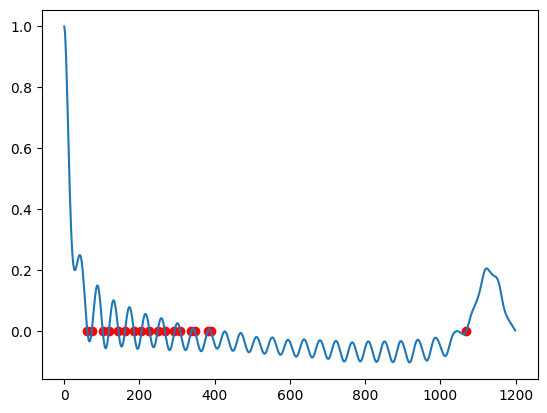

In [28]:
# Compute autocorrelation of x (shape: 32, 1200, 1), averaged over 32 trials
x_np = x.numpy().squeeze(-1)        # shape: (32, 1200)
n_trials, n_timepoints = x_np.shape
autocorrs = []
for i in range(n_trials):
    xi = x_np[i] - np.mean(x_np[i])
    ac = np.correlate(xi, xi, mode='full')
    ac = ac[ac.size // 2:]                  # keep non-negative lags
    ac /= ac[0]                             # normalize (autocorr at lag 0 = 1)
    autocorrs.append(ac)
autocorr_mean = np.mean(np.stack(autocorrs, axis=0), axis=0)  # shape: (1200,)

plt.plot(autocorr_mean)
# find the first zero crossing of the autocorrelation
zero_crossings = np.where(np.diff(np.sign(autocorr_mean)))[0]
print(f"Zero crossings: {zero_crossings}")
plt.scatter(zero_crossings, np.zeros_like(zero_crossings), c="red")
plt.show()


In [57]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
amplification_losses = {}
fnn_losses = {}
fnn_weights_avg = {}

import torch

def compute_fnn_metric(
    x_prev: torch.Tensor, 
    x_test: torch.Tensor, 
    k: int = 10, 
    rtol: float = 20.0, 
    atol: float = 2.0, 
    n_samples: int = None
) -> float:
    """
    Computes the percentage of False Nearest Neighbors of x_prev when embedded into x_test.
    Exactly matches the Kennel et al. math used in loss_false.
    
    Parameters
    ----------
    x_prev : torch.Tensor
        (batch_size, D_prev) tensor of the base embedding.
    x_test : torch.Tensor
        (batch_size, D_test) tensor of the higher-dimensional embedding.
    k : int
        Number of nearest neighbors to evaluate.
    rtol : float
        Relative tolerance threshold for distance expansion.
    atol : float
        Absolute tolerance threshold for distance expansion.
    n_samples : int or None
        Optional random subsampling to prevent O(N^2) memory explosion.
        
    Returns
    -------
    float
        The fraction of false nearest neighbors (0.0 to 1.0).
    """
    # Subsampling
    if n_samples is not None and len(x_prev) > n_samples:
        idx = torch.randperm(len(x_prev), device=x_prev.device)[:n_samples]
        x_prev = x_prev[idx]
        x_test = x_test[idx]

    # Compute pairwise squared distances for x_prev
    x_prev_sq = (x_prev * x_prev).sum(dim=1, keepdim=True)
    dist_prev = x_prev_sq + x_prev_sq.T - 2 * torch.mm(x_prev, x_prev.T)
    dist_prev = torch.clamp(dist_prev, min=1e-14)

    # Compute pairwise squared distances for x_test
    x_test_sq = (x_test * x_test).sum(dim=1, keepdim=True)
    dist_test = x_test_sq + x_test_sq.T - 2 * torch.mm(x_test, x_test.T)
    dist_test = torch.clamp(dist_test, min=1e-14)

    # Characteristic scale of x_prev (mean of the coordinate variances)
    ra_squared = torch.mean(torch.std(x_prev, dim=0)**2)

    # Find k+1 nearest neighbors in the LOWER dimension (x_prev)
    _, inds = torch.topk(-dist_prev, k + 1, dim=-1)

    # Gather the distances to those exact neighbors in both spaces
    neighbor_dists_prev = torch.gather(dist_prev, 1, inds)
    neighbor_dists_test = torch.gather(dist_test, 1, inds)

    # Kennel Condition 1: Relative distance change exceeds rtol
    scaled_dist_squared = torch.clamp(
        (neighbor_dists_test - neighbor_dists_prev) / neighbor_dists_prev,
        min=0.0
    )
    is_false_change = scaled_dist_squared > rtol**2

    # Kennel Condition 2: Absolute distance jump exceeds attractor scale
    is_large_jump = neighbor_dists_test > atol**2 * ra_squared

    # A neighbor is false if it violates EITHER condition
    is_false_neighbor = is_false_change | is_large_jump

    # Drop the first column (distance to self is always 0)
    total_false_neighbors = is_false_neighbor[:, 1:(k + 1)]

    # Return the scalar fraction of false neighbors
    return total_false_neighbors.float().mean().item()

if DATA_SOURCE == "wmtask":
    N_DELAYS_VALS = np.arange(1, 16)
    INTERVAL_VALS = [1]
    MAX_T = 30
else:
    N_DELAYS_VALS = np.arange(1, 101)
    # N_DELAYS_VALS = [10]
    # INTERVAL_VALS = np.arange(1, 21)
    # INTERVAL_VALS = np.arange(1, zero_crossings[0])
    # INTERVAL_VALS = [zero_crossings[0]]
    # INTERVAL_VALS = [10]
    INTERVAL_VALS = [1]
    MAX_T = 30

iterator = tqdm(total=len(N_DELAYS_VALS) * len(INTERVAL_VALS))
x_prev = None
for n_delays in N_DELAYS_VALS:
    for delay_interval in INTERVAL_VALS:
        if x.shape[1] - (n_delays - 1) * delay_interval <= 0: # use at least half the data
            print(f"Skipping n_delays={n_delays}, delay_interval={delay_interval} because x.shape[1] - (n_delays - 1) * delay_interval <= 0")
            iterator.update(1)
            continue
        x_embedded = embed_signal_torch(x, n_delays, delay_interval)
        x_embedded = x_embedded.to(device)
        x_data = x_embedded[..., :x.shape[-1]]

        if x_embedded.shape[1] < x.shape[1]*(0.5): # use at least half the data
            print(f"Skipping n_delays={n_delays}, delay_interval={delay_interval} because x_embedded.shape[1] < x.shape[1]*(0.5)")
            iterator.update(1)
            continue

        loss = loss_amplification(x_embedded, x_data.to(device), max_T=MAX_T, n_neighbors=10,normalize=True)
        amplification_losses[(n_delays, delay_interval)] = loss.item()
        # loss_fnn, fnn_weights = loss_false(
        #                 x_embedded.reshape(-1, x_embedded.shape[-1]), 
        #                 k=10, normalize=True, 
        #                 # use_pca=True, 
        #                 use_pca=False,
        #                 elementwise_regularization=True, 
        #                 # elementwise_regularization=False,
        #                 return_fnn_weights=True,
        #                 # n_samples=1024
        #                 n_samples=4096
        #             )
        # # raise ValueError("Stop here")
        # fnn_losses[(n_delays, delay_interval)] = loss_fnn.item()
        # fnn_weights_avg[(n_delays, delay_interval)] = 1 - fnn_weights.mean(dim=0)

        obs_dim = x.shape[-1]
        x_test_flat = x_embedded.reshape(-1, x_embedded.shape[-1])

        if n_delays == 1:
            fnn_losses[(n_delays, delay_interval)] = 1.0
        else:
            # x_prev is just x_test without the oldest delay block!
            # This guarantees 100% perfect timepoint alignment.
            x_prev_flat = x_test_flat[:, obs_dim:]

            fnn_losses[(n_delays, delay_interval)] = compute_fnn_metric(
                x_prev=x_prev_flat,
                x_test=x_test_flat,
                k=10,  # Kennel traditionally uses 10 to ensure a robust neighborhood
                n_samples=4096
            )
        iterator.update(1)
iterator.close()

  0%|          | 0/100 [00:00<?, ?it/s]

/tmp/ipykernel_3891992/2554729816.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis").copy()


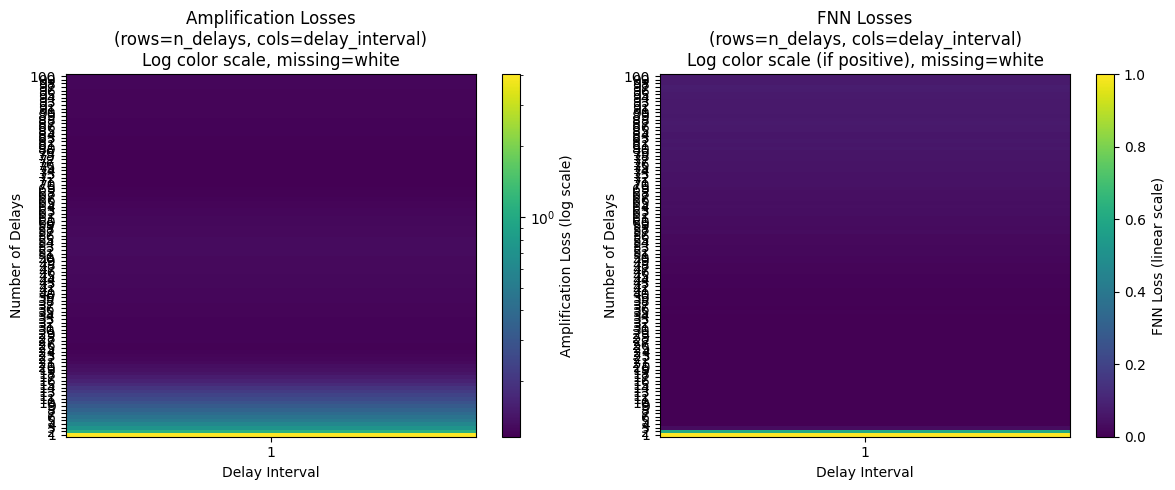

In [58]:
import numpy as np
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt

# Convert the amplification_losses and fnn_losses dicts to 2D arrays for plotting
n_delays_max = max(N_DELAYS_VALS)
interval_max = max(INTERVAL_VALS)

# Use np.full with np.nan, so missing entries are np.nan (shows up as white)
amplification_loss_matrix = np.full((n_delays_max, interval_max), np.nan)
fnn_loss_matrix = np.full((n_delays_max, interval_max), np.nan)
for (n_delays, delay_interval), loss in amplification_losses.items():
    amplification_loss_matrix[n_delays-1, delay_interval-1] = float(loss)
for (n_delays, delay_interval), loss in fnn_losses.items():
    fnn_loss_matrix[n_delays-1, delay_interval-1] = float(loss)

# Mask nan values to display them as white by using a colormap with nan color set to white
from matplotlib import cm
cmap = cm.get_cmap("viridis").copy()
cmap.set_bad(color='white')

# Normalization for log scale (amplification loss)
non_nan_amp = np.isfinite(amplification_loss_matrix)
if np.any(non_nan_amp):
    vmin_amp = np.nanmin(amplification_loss_matrix)
    vmax_amp = np.nanmax(amplification_loss_matrix)
else:
    vmin_amp, vmax_amp = 1, 10  # fallback

# Normalization for fnn (can be log if strictly positive, else linear)
non_nan_fnn = np.isfinite(fnn_loss_matrix)
if np.any(non_nan_fnn):
    vmin_fnn = np.nanmin(fnn_loss_matrix)
    vmax_fnn = np.nanmax(fnn_loss_matrix)
else:
    vmin_fnn, vmax_fnn = 1e-2, 1  # fallback

# Try using a linear color scale if no negative/zero values, else fallback to LogNorm
fnn_strictly_positive = np.nanmin(fnn_loss_matrix) > 0
norm_fnn = LogNorm(vmin=max(vmin_fnn, 1e-8), vmax=vmax_fnn) if fnn_strictly_positive else None

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

im0 = axs[0].imshow(
    np.ma.masked_invalid(amplification_loss_matrix),
    origin="lower",
    aspect="auto",
    cmap=cmap,
    norm=LogNorm(vmin=vmin_amp, vmax=vmax_amp),
)
cbar0 = plt.colorbar(im0, ax=axs[0], label='Amplification Loss (log scale)')

im1 = axs[1].imshow(
    np.ma.masked_invalid(fnn_loss_matrix),
    origin="lower",
    aspect="auto",
    cmap=cmap,
    norm=norm_fnn,
)
if fnn_strictly_positive:
    cbar1 = plt.colorbar(im1, ax=axs[1], label='FNN Loss (log scale)')
else:
    cbar1 = plt.colorbar(im1, ax=axs[1], label='FNN Loss (linear scale)')

# Set tick labels for both subplots
for ax in axs:
    ax.set_xticks(np.arange(interval_max))
    ax.set_yticks(np.arange(n_delays_max))
    ax.set_xticklabels(np.arange(1, interval_max + 1))
    ax.set_yticklabels(np.arange(1, n_delays_max + 1))
    ax.set_xlabel("Delay Interval")
    ax.set_ylabel("Number of Delays")

axs[0].set_title("Amplification Losses\n(rows=n_delays, cols=delay_interval)\nLog color scale, missing=white")
axs[1].set_title("FNN Losses\n(rows=n_delays, cols=delay_interval)\nLog color scale (if positive), missing=white")

plt.tight_layout()
plt.show()

Text(0, 0.5, 'FNN Loss')

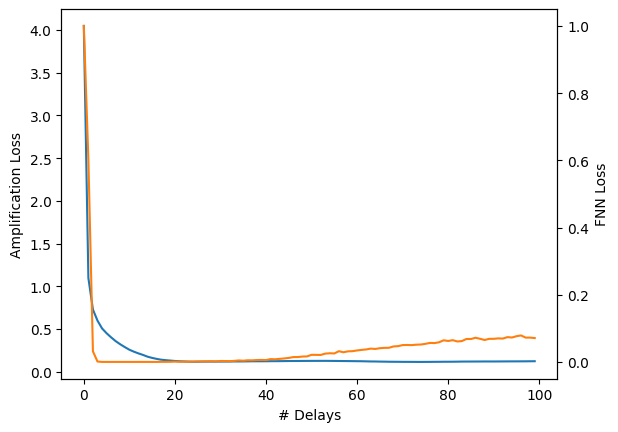

In [67]:
plt.plot(amplification_loss_matrix)
plt.ylabel('Amplification Loss')
plt.xlabel('# Delays')
ax2 = plt.gca().twinx()
ax2.plot(fnn_loss_matrix, c="C1")
ax2.set_ylabel('FNN Loss')


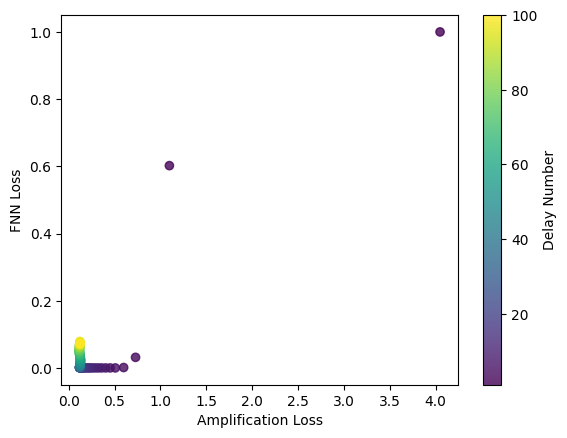

In [61]:
# Color the scatter plot by delay number (y-axis index)
n_delays = amplification_loss_matrix.shape[0]
delay_numbers = np.arange(1, n_delays + 1)
colors = delay_numbers[:, None] * np.ones_like(amplification_loss_matrix)

plt.scatter(
    amplification_loss_matrix.flatten(),
    fnn_loss_matrix.flatten(),
    c=np.repeat(delay_numbers, amplification_loss_matrix.shape[1]),
    cmap="viridis",
    alpha=0.8
)
plt.xlabel('Amplification Loss')
plt.ylabel('FNN Loss')
# plt.xscale('log')
# plt.yscale('log')
cbar = plt.colorbar(label='Delay Number')
plt.show()

In [62]:
import numpy as np
from scipy.stats import spearmanr

def auto_optimal_delay(fnn_scores, amp_scores):
    fnn = np.array(fnn_scores)
    amp = np.array(amp_scores)
    
    # Normalize to [0, 1] to make the space unitless
    fnn_norm = (fnn - np.min(fnn)) / (np.max(fnn) - np.min(fnn))
    amp_norm = (amp - np.min(amp)) / (np.max(amp) - np.min(amp))
    
    # Calculate Spearman rank correlation
    corr, _ = spearmanr(fnn, amp)
    print(f"Spearman Rank Correlation: {corr:.4f}")
    
    # ROUTE 1: Metrics Agree (Positive Correlation)
    if corr > 0:
        print("Logic: Metrics agree. Using Utopia Point Method.")
        distances = np.sqrt(fnn_norm**2 + amp_norm**2)
        optimal_idx = np.argmin(distances)
        
    # ROUTE 2: Metrics Trade-off (Negative Correlation)
    else:
        print("Logic: Trade-off detected. Using Geometric Chord Method.")
        idx_min_fnn = np.argmin(fnn_norm)
        idx_min_amp = np.argmin(amp_norm)
        
        # Edge Case: Global optimum exists despite negative macro-correlation
        if idx_min_fnn == idx_min_amp:
            optimal_idx = idx_min_fnn
        else:
            p_A = np.array([fnn_norm[idx_min_fnn], amp_norm[idx_min_fnn]])
            p_B = np.array([fnn_norm[idx_min_amp], amp_norm[idx_min_amp]])
            
            v = p_B - p_A
            v_mag = np.linalg.norm(v)
            
            if v_mag < 1e-8:
                optimal_idx = idx_min_fnn
            else:
                distances = []
                for i in range(len(fnn)):
                    p_i = np.array([fnn_norm[i], amp_norm[i]])
                    u = p_i - p_A
                    cross_prod = np.abs(v[0] * u[1] - v[1] * u[0])
                    distances.append(cross_prod / v_mag)
                    
                optimal_idx = np.argmax(distances)

    print(f"\nFinal Optimal Delay Index: {optimal_idx}")
    fnn_val = fnn[optimal_idx]
    amp_val = amp[optimal_idx]
    # If the selection from fnn/amp is an ndarray (e.g., from 2D input), take just the scalar value
    if isinstance(fnn_val, np.ndarray):
        fnn_val = fnn_val.item()
    if isinstance(amp_val, np.ndarray):
        amp_val = amp_val.item()
    print(f"  FNN Score: {fnn_val:.4f}")
    print(f"  Amp Score: {amp_val:.4f}")
    
    return optimal_idx
optimal_idx = auto_optimal_delay(fnn_loss_matrix, amplification_loss_matrix)
print(f"Optimal Delay Index: {optimal_idx}")

Spearman Rank Correlation: -0.4556
Logic: Trade-off detected. Using Geometric Chord Method.

Final Optimal Delay Index: 0
  FNN Score: 1.0000
  Amp Score: 4.0484
Optimal Delay Index: 0


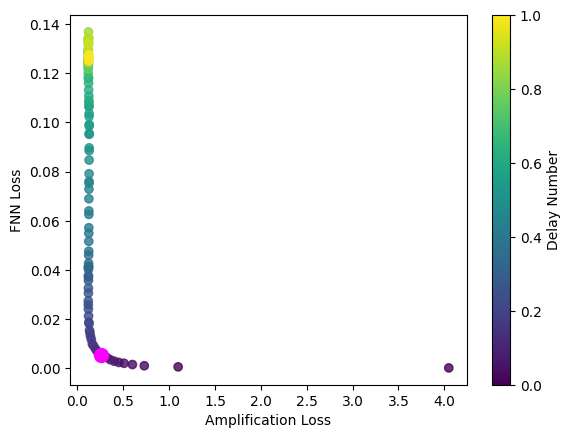

In [14]:
# Color the scatter plot by delay number (y-axis index)
n_delays = amplification_loss_matrix.shape[0]
delay_numbers = np.arange(1, n_delays + 1)
colors = delay_numbers[:, None] * np.ones_like(amplification_loss_matrix)

plt.scatter(
    amplification_loss_matrix.flatten(),
    fnn_loss_matrix.flatten(),
    c=np.repeat(delay_numbers, amplification_loss_matrix.shape[1]),
    cmap="viridis",
    alpha=0.8
)
plt.xlabel('Amplification Loss')
plt.ylabel('FNN Loss')
# plt.xscale('log')
plt.scatter(amplification_loss_matrix[optimal_idx], fnn_loss_matrix[optimal_idx], c="magenta", s=100)
cbar = plt.colorbar(label='Delay Number')
plt.show()

In [17]:
fnn_loss_matrix

array([[0.        ],
       [0.00043379],
       [0.00088791],
       [0.00138413],
       [0.00188891],
       [0.00224489],
       [0.0027218 ],
       [0.00332864],
       [0.00420411],
       [0.00447356],
       [0.0050722 ],
       [0.00625497],
       [0.00671531],
       [0.00771246],
       [0.00892591],
       [0.0097423 ],
       [0.01160677],
       [0.01297323],
       [0.01434112],
       [0.01528882],
       [0.01806051],
       [0.01862128],
       [0.02117125],
       [0.02396623],
       [0.02573748],
       [0.02727894],
       [0.03048081],
       [0.03251603],
       [0.03702484],
       [0.03560619],
       [0.03766669],
       [0.04024122],
       [0.04083095],
       [0.04132789],
       [0.04134619],
       [0.04265762],
       [0.04595994],
       [0.04753333],
       [0.05158848],
       [0.05486147],
       [0.05711244],
       [0.06254225],
       [0.06397793],
       [0.06890889],
       [0.07282905],
       [0.07530873],
       [0.07597297],
       [0.079

In [16]:
optimal_idx = auto_optimal_delay(np.log(fnn_loss_matrix), np.log(amplification_loss_matrix))
print(f"Optimal Delay Index: {optimal_idx}")

Spearman Rank Correlation: -0.6496
Logic: Trade-off detected. Using Geometric Chord Method.

Final Optimal Delay Index: 0
  FNN Score: -inf
  Amp Score: 1.3983
Optimal Delay Index: 0


/tmp/ipykernel_3891992/1579436453.py:1: RuntimeWarning: divide by zero encountered in log
  optimal_idx = auto_optimal_delay(np.log(fnn_loss_matrix), np.log(amplification_loss_matrix))
/tmp/ipykernel_3891992/2953708089.py:9: RuntimeWarning: invalid value encountered in subtract
  fnn_norm = (fnn - np.min(fnn)) / (np.max(fnn) - np.min(fnn))
/tmp/ipykernel_3891992/2953708089.py:9: RuntimeWarning: invalid value encountered in divide
  fnn_norm = (fnn - np.min(fnn)) / (np.max(fnn) - np.min(fnn))


In [ ]:
# Find the (n_delays, delay_interval) that gives the minimum amplification loss
best_amp_params = min(amplification_losses, key=amplification_losses.get)
best_amp_n_delays, best_amp_delay_interval = best_amp_params
best_amp_loss = amplification_losses[best_amp_params]

print(f"Best amplification loss: {best_amp_loss:.5g} at n_delays={best_amp_n_delays}, delay_interval={best_amp_delay_interval}")

# Generate the embedding with these optimal parameters for amplification loss
best_amp_x_embedded = embed_signal_torch(x, best_amp_n_delays, best_amp_delay_interval)

# Also find the minimum amplification loss when delay_interval == 1
amp_candidates_delay1 = {k: v for k, v in amplification_losses.items() if k[1] == 1}
if amp_candidates_delay1:
    best_amp_params_delay1 = min(amp_candidates_delay1, key=amp_candidates_delay1.get)
    best_amp_n_delays_delay1, best_amp_delay_interval_delay1 = best_amp_params_delay1
    best_amp_loss_delay1 = amplification_losses[best_amp_params_delay1]
    print(f"Best amplification loss (delay_interval=1): {best_amp_loss_delay1:.5g} at n_delays={best_amp_n_delays_delay1}, delay_interval={best_amp_delay_interval_delay1}")

    # Generate the embedding with these optimal parameters for amplification loss at delay_interval=1
    best_amp_x_embedded_delay1 = embed_signal_torch(x, best_amp_n_delays_delay1, best_amp_delay_interval_delay1)
else:
    print("No amplification losses found with delay_interval=1; skipping best amplification embedding with delay_interval=1.")
    best_amp_x_embedded_delay1 = None

# Find the (n_delays, delay_interval) that gives the minimum FNN loss (excluding n_delays=1)
if len(fnn_losses) > 0:
    # Exclude n_delays == 1 from candidates
    fnn_candidates = {k: v for k, v in fnn_losses.items() if k[0] > 1}
    if fnn_candidates:
        best_fnn_params = min(fnn_candidates, key=fnn_candidates.get)
        best_fnn_n_delays, best_fnn_delay_interval = best_fnn_params
        best_fnn_loss = fnn_losses[best_fnn_params]
        print(f"Best FNN loss (n_delays > 1): {best_fnn_loss:.5g} at n_delays={best_fnn_n_delays}, delay_interval={best_fnn_delay_interval}")

        # Generate the embedding with these optimal parameters for FNN loss
        best_fnn_x_embedded = embed_signal_torch(x, best_fnn_n_delays, best_fnn_delay_interval)
    else:
        print("No FNN losses found with n_delays > 1; skipping best FNN embedding.")
        best_fnn_x_embedded = None
else:
    print("No FNN losses found; skipping best FNN embedding.")
    best_fnn_x_embedded = None

Best amplification loss: 0.11593 at n_delays=75, delay_interval=1
Best amplification loss (delay_interval=1): 0.11593 at n_delays=75, delay_interval=1
Best FNN loss (n_delays > 1): 0.00044448 at n_delays=2, delay_interval=1


Amp Chosen Embedding Participation Ratio: 1.445
Dimensions for 99% var (amplification-optimal): 6
Amp Embedding (delay_interval=1) Participation Ratio: 1.445
Dimensions for 99% var (amplification, delay=1): 6
FNN Chosen Embedding Participation Ratio: 1.002
Dimensions for 99% var (FNN-optimal): 1
Optimal (idx=11) Embedding Participation Ratio: 1.064
Dimensions for 99% var (optimal_idx): 2


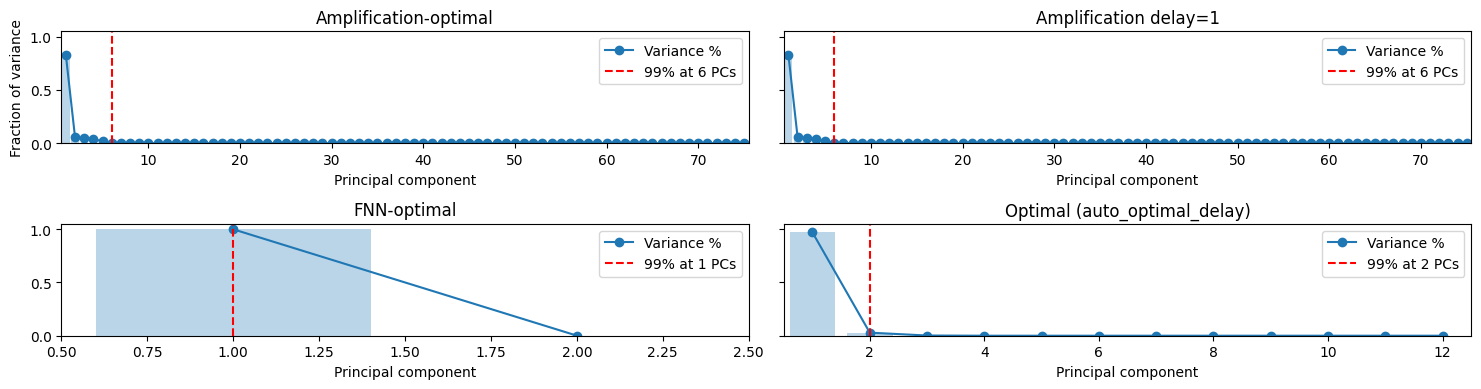

In [21]:
# --- Participation ratio, PCA projection, and scree plots for best amplification embedding ---
amp_emb_pca = None
amp_emb_eigvals = None
amp_emb_n99 = None

if 'best_amp_x_embedded' in locals() and best_amp_x_embedded is not None:
    amp_emb_flat = best_amp_x_embedded.reshape(-1, best_amp_x_embedded.shape[-1])
    amp_emb_flat_centered = amp_emb_flat - torch.mean(amp_emb_flat, dim=0, keepdim=True)
    amp_emb_cov = torch.cov(amp_emb_flat_centered.T)
    amp_emb_eigvals, amp_emb_eigvecs = torch.linalg.eigh(amp_emb_cov)
    amp_emb_eigvals = amp_emb_eigvals.flip(dims=(0,))
    amp_emb_eigvecs = amp_emb_eigvecs.flip(dims=(1,))
    amp_emb_pr = (amp_emb_eigvals.sum())**2 / (amp_emb_eigvals**2).sum()
    amp_emb_var_cumsum = torch.cumsum(amp_emb_eigvals, 0) / torch.sum(amp_emb_eigvals)
    amp_emb_n99 = int((amp_emb_var_cumsum < 0.99).sum().item() + 1)
    print(f"Amp Chosen Embedding Participation Ratio: {amp_emb_pr.item():.3f}")
    print(f"Dimensions for 99% var (amplification-optimal): {amp_emb_n99}")
    amp_emb_pca = amp_emb_flat_centered @ amp_emb_eigvecs

# --- Participation ratio, PCA projection, and scree plots for best amplification embedding with delay_interval=1 ---
amp_emb_pca_delay1 = None
amp_emb_eigvals_delay1 = None
amp_emb_n99_delay1 = None
if 'best_amp_x_embedded_delay1' in locals() and best_amp_x_embedded_delay1 is not None:
    amp_emb_flat_delay1 = best_amp_x_embedded_delay1.reshape(-1, best_amp_x_embedded_delay1.shape[-1])
    amp_emb_flat_centered_delay1 = amp_emb_flat_delay1 - torch.mean(amp_emb_flat_delay1, dim=0, keepdim=True)
    amp_emb_cov_delay1 = torch.cov(amp_emb_flat_centered_delay1.T)
    amp_emb_eigvals_delay1, amp_emb_eigvecs_delay1 = torch.linalg.eigh(amp_emb_cov_delay1)
    amp_emb_eigvals_delay1 = amp_emb_eigvals_delay1.flip(dims=(0,))
    amp_emb_eigvecs_delay1 = amp_emb_eigvecs_delay1.flip(dims=(1,))
    amp_emb_pr_delay1 = (amp_emb_eigvals_delay1.sum())**2 / (amp_emb_eigvals_delay1**2).sum()
    amp_emb_var_cumsum_delay1 = torch.cumsum(amp_emb_eigvals_delay1, 0) / torch.sum(amp_emb_eigvals_delay1)
    amp_emb_n99_delay1 = int((amp_emb_var_cumsum_delay1 < 0.99).sum().item() + 1)
    print(f"Amp Embedding (delay_interval=1) Participation Ratio: {amp_emb_pr_delay1.item():.3f}")
    print(f"Dimensions for 99% var (amplification, delay=1): {amp_emb_n99_delay1}")
    amp_emb_pca_delay1 = amp_emb_flat_centered_delay1 @ amp_emb_eigvecs_delay1

# --- Participation ratio, PCA projection, and scree plots for best FNN embedding ---
fnn_emb_pca = None
fnn_emb_eigvals = None
fnn_emb_n99 = None
if 'best_fnn_x_embedded' in locals() and best_fnn_x_embedded is not None:
    fnn_emb_flat = best_fnn_x_embedded.reshape(-1, best_fnn_x_embedded.shape[-1])
    fnn_emb_flat_centered = fnn_emb_flat - torch.mean(fnn_emb_flat, dim=0, keepdim=True)
    fnn_emb_cov = torch.cov(fnn_emb_flat_centered.T)
    fnn_emb_eigvals, fnn_emb_eigvecs = torch.linalg.eigh(fnn_emb_cov)
    fnn_emb_eigvals = fnn_emb_eigvals.flip(dims=(0,))
    fnn_emb_eigvecs = fnn_emb_eigvecs.flip(dims=(1,))
    fnn_emb_pr = (fnn_emb_eigvals.sum())**2 / (fnn_emb_eigvals**2).sum()
    fnn_emb_var_cumsum = torch.cumsum(fnn_emb_eigvals, 0) / torch.sum(fnn_emb_eigvals)
    fnn_emb_n99 = int((fnn_emb_var_cumsum < 0.99).sum().item() + 1)
    print(f"FNN Chosen Embedding Participation Ratio: {fnn_emb_pr.item():.3f}")
    print(f"Dimensions for 99% var (FNN-optimal): {fnn_emb_n99}")
    fnn_emb_pca = fnn_emb_flat_centered @ fnn_emb_eigvecs

# --- Participation ratio, PCA projection for optimal_idx (delay embedding chosen by auto_optimal_delay) ---
opt_emb_pca = None
opt_emb_eigvals = None
opt_emb_n99 = None
if 'optimal_idx' in locals() and 'amplification_loss_matrix' in locals() and 'x' in locals():
    n_rows, n_cols = amplification_loss_matrix.shape
    opt_row = optimal_idx // n_cols
    opt_col = optimal_idx % n_cols
    opt_n_delays = opt_row + 1
    opt_delay_interval = opt_col + 1
    best_opt_x_embedded = embed_signal_torch(x, opt_n_delays, opt_delay_interval)
    opt_emb_flat = best_opt_x_embedded.reshape(-1, best_opt_x_embedded.shape[-1])
    opt_emb_flat_centered = opt_emb_flat - torch.mean(opt_emb_flat, dim=0, keepdim=True)
    opt_emb_cov = torch.cov(opt_emb_flat_centered.T)
    opt_emb_eigvals, opt_emb_eigvecs = torch.linalg.eigh(opt_emb_cov)
    opt_emb_eigvals = opt_emb_eigvals.flip(dims=(0,))
    opt_emb_eigvecs = opt_emb_eigvecs.flip(dims=(1,))
    opt_emb_pr = (opt_emb_eigvals.sum())**2 / (opt_emb_eigvals**2).sum()
    opt_emb_var_cumsum = torch.cumsum(opt_emb_eigvals, 0) / torch.sum(opt_emb_eigvals)
    opt_emb_n99 = int((opt_emb_var_cumsum < 0.99).sum().item() + 1)
    print(f"Optimal (idx={optimal_idx}) Embedding Participation Ratio: {opt_emb_pr.item():.3f}")
    print(f"Dimensions for 99% var (optimal_idx): {opt_emb_n99}")
    opt_emb_pca = opt_emb_flat_centered @ opt_emb_eigvecs

# --- Scree plots for all four cases ---
import matplotlib.pyplot as plt

fig_scree, axs_scree = plt.subplots(2, 2, figsize=(15, 4), sharey=True)
axs_scree = axs_scree.flatten()
cases = [
    ('Amplification-optimal', amp_emb_eigvals, amp_emb_n99),
    ('Amplification delay=1', amp_emb_eigvals_delay1, amp_emb_n99_delay1),
    ('FNN-optimal', fnn_emb_eigvals, fnn_emb_n99),
    ('Optimal (auto_optimal_delay)', opt_emb_eigvals, opt_emb_n99)
]
for i, (label, eigvals, n99) in enumerate(cases):
    if eigvals is not None:
        eigvals_np = eigvals.detach().cpu().numpy() if hasattr(eigvals, "detach") else eigvals
        total_var = eigvals_np.sum()
        explained_var = eigvals_np / total_var
        cumsum = explained_var.cumsum()
        axs_scree[i].plot(np.arange(1, len(eigvals_np) + 1), explained_var, marker='o', label="Variance %")
        axs_scree[i].set_title(label)
        axs_scree[i].set_xlabel("Principal component")
        axs_scree[i].set_ylabel("Fraction of variance" if i==0 else "")
        axs_scree[i].bar(np.arange(1, len(eigvals_np) + 1), explained_var, alpha=0.3, color='C0')
        axs_scree[i].axvline(n99, ls='--', color='r', label=f"99% at {n99} PCs")
        axs_scree[i].legend()
        axs_scree[i].set_ylim(0, 1.05)
        axs_scree[i].set_xlim(0.5, len(eigvals_np) + 0.5)
    else:
        axs_scree[i].set_visible(False)
plt.tight_layout()
plt.show()

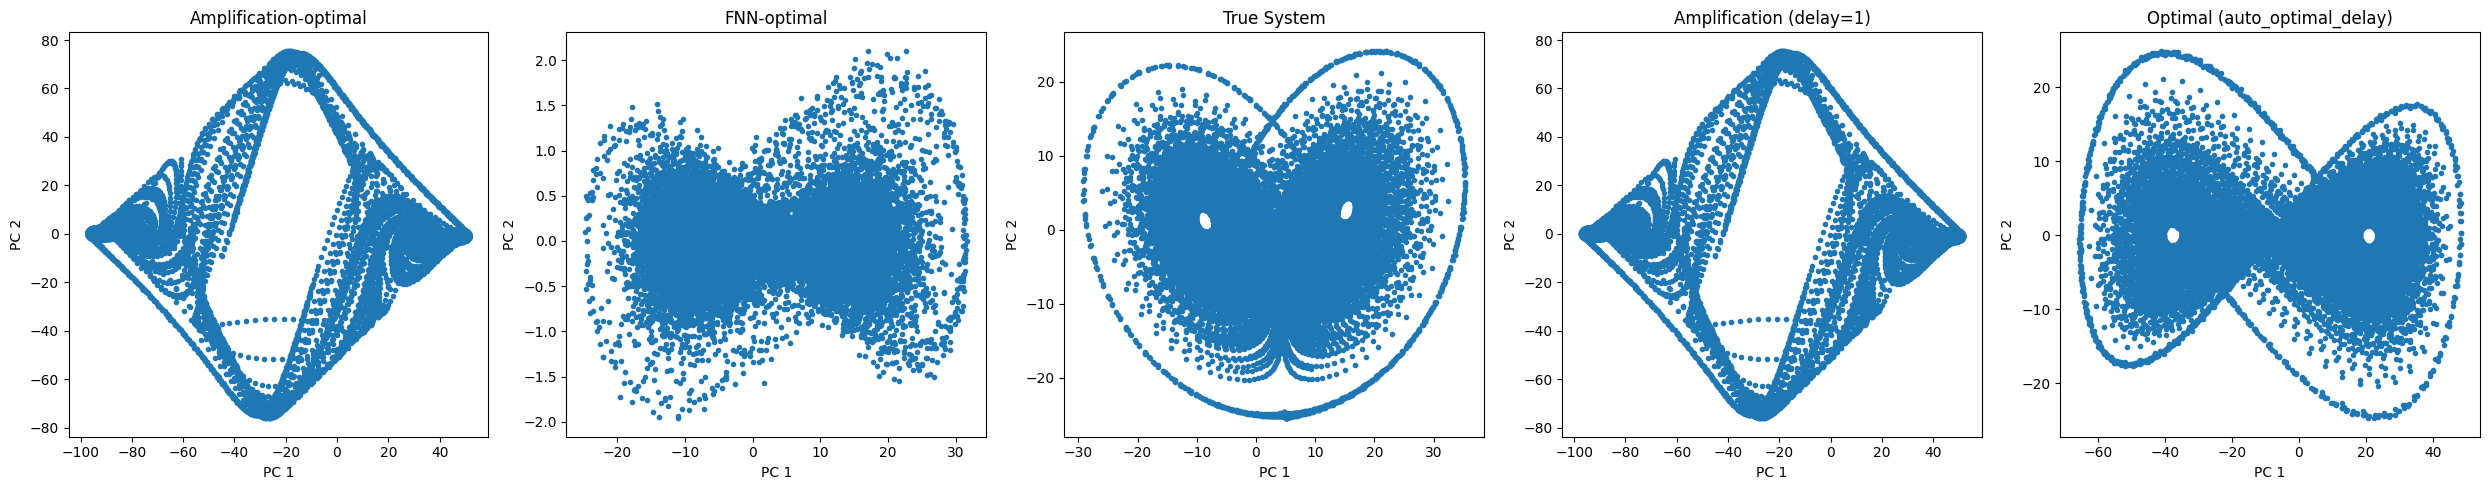

In [23]:
fig, axs = plt.subplots(1, 5, figsize=(25, 5))

# 1. Chosen amplification-optimal embedding (if available)
if amp_emb_pca is not None:
    axs[0].plot(amp_emb_pca[:, 0], amp_emb_pca[:, 1], '.')
    axs[0].set_title('Amplification-optimal')
    axs[0].set_xlabel('PC 1')
    axs[0].set_ylabel('PC 2')
else:
    axs[0].set_visible(False)
    axs[0].set_title('No Amplification-optimal')

# 2. FNN-optimal embedding (if available)
if fnn_emb_pca is not None:
    axs[1].plot(fnn_emb_pca[:, 0], fnn_emb_pca[:, 1], '.')
    axs[1].set_title('FNN-optimal')
    axs[1].set_xlabel('PC 1')
    axs[1].set_ylabel('PC 2')
else:
    axs[1].set_visible(False)
    axs[1].set_title('No FNN-optimal')

# 3. True system embedding PCA (recompute here from values_raw, if available)
if "values_raw" in locals():
    # Assume values_raw: (timesteps, features) torch tensor or numpy array
    if isinstance(values_raw, torch.Tensor):
        values_raw_flat = values_raw.reshape(-1, values_raw.shape[-1])
        mean = torch.mean(values_raw_flat, dim=0, keepdim=True)
        values_flat_centered = values_raw_flat - mean
        cov = torch.cov(values_flat_centered.T)
        eigvals, eigvecs = torch.linalg.eigh(cov)
        eigvecs = eigvecs.flip(dims=(1,))
        values_pca = values_flat_centered @ eigvecs
        values_pca_np = values_pca.detach().cpu().numpy()
    else:
        # Assume numpy
        values_raw_flat = values_raw.reshape(-1, values_raw.shape[-1])
        mean = values_raw_flat.mean(axis=0, keepdims=True)
        values_flat_centered = values_raw_flat - mean
        cov = np.cov(values_flat_centered.T)
        eigvals, eigvecs = np.linalg.eigh(cov)
        eigvecs = np.flip(eigvecs, axis=1)
        values_pca_np = values_flat_centered @ eigvecs
    axs[2].plot(values_pca_np[:, 0], values_pca_np[:, 1], '.')
    axs[2].set_title('True System')
    axs[2].set_xlabel('PC 1')
    axs[2].set_ylabel('PC 2')
else:
    axs[2].set_visible(False)
    axs[2].set_title('No True System Data')

# 4. Delay-1 amplification embedding PCA (if available)
if amp_emb_pca_delay1 is not None:
    axs[3].plot(amp_emb_pca_delay1[:, 0], amp_emb_pca_delay1[:, 1], '.')
    axs[3].set_title('Amplification (delay=1)')
    axs[3].set_xlabel('PC 1')
    axs[3].set_ylabel('PC 2')
else:
    axs[3].set_visible(False)
    axs[3].set_title('No Delay=1 Amplification')

# 5. Optimal (auto_optimal_delay) embedding PCA (if available)
if opt_emb_pca is not None:
    axs[4].plot(opt_emb_pca[:, 0], opt_emb_pca[:, 1], '.')
    axs[4].set_title('Optimal (auto_optimal_delay)')
    axs[4].set_xlabel('PC 1')
    axs[4].set_ylabel('PC 2')
else:
    axs[4].set_visible(False)
    axs[4].set_title('No Optimal Embedding')

plt.tight_layout()
plt.show()